<a href="https://colab.research.google.com/github/Shardenov99/Coursera_Course_Analysis/blob/main/Coursera_Course_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Coursera Course Dataset

This project dives deeper and analyzes the coursera course dataset using Python and Plotly to uncover patterns in enrollment behaviour and learner feedback.
The aim is to understand how course structure, difficulty, and provider influence both popularity and quality.

My goals for this project are to:
- Clean and prepare the data for analysis.
- Identify the top-performing organizations and most popular courses.
- Explore how learners engage with different course structures and certification types.
- Detect interesting patterns and correlations in the data.

# Data Cleaning

Before diving into analysis, I cleaned and prepared the dataset to ensure consistency and accuracy. The steps included:
- Handling null values<br>
- Converting data types<br>
- Fixing inconsistent formatting<br>
- Checking for duplicates.<br>

### I begin by importing the dataset and inspecting the first few rows

In [ ]:
import chart_studio.plotly as py
import cufflinks as cf
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
import seaborn as sns
import matplotlib.pyplot as plt
from plotly.offline import download_plotlyjs, init_notebook_mode, iplot, plot

%matplotlib inline

init_notebook_mode(connected=True)

cf.go_offline()

In [ ]:
df = pd.read_csv("coursea_data.csv", index_col=0)
df = df.reset_index(drop=True)
df.head()

,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
0,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5.3k
1,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17k
2,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130k
3,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91k
4,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320k


In [ ]:
df.tail()

,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
886,Программирование на Python,Mail.Ru Group,SPECIALIZATION,4.5,Intermediate,52k
887,Психолингвистика (Psycholinguistics),Saint Petersburg State University,COURSE,4.8,Mixed,21k
888,Разработка интерфейсов: вёрстка и JavaScript,E-Learning Development Fund,SPECIALIZATION,4.5,Intermediate,30k
889,Русский как иностранный,Saint Petersburg State University,SPECIALIZATION,4.6,Intermediate,9.8k
890,Финансовые инструменты для частного инвестора,National Research University Higher School of ...,SPECIALIZATION,4.7,Beginner,38k


### Clean up the data
- Convert all column names to lowercase for consitancy.
- Check for null values, empty strings and duplicated rows in the data.
- Convert Categorical columns into Category data type.

In [ ]:
df.columns = df.columns.str.lower()

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   course_title              891 non-null    object 
 1   course_organization       891 non-null    object 
 2   course_certificate_type   891 non-null    object 
 3   course_rating             891 non-null    float64
 4   course_difficulty         891 non-null    object 
 5   course_students_enrolled  891 non-null    object 
dtypes: float64(1), object(5)
memory usage: 41.9+ KB


course_title                0
course_organization         0
course_certificate_type     0
course_rating               0
course_difficulty           0
course_students_enrolled    0
dtype: int64

In [ ]:
categorical_columns = [
    "course_title",
    "course_organization",
    "course_certificate_type",
    "course_difficulty",
]
df[categorical_columns] = df[categorical_columns].astype("category")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   course_title              891 non-null    category
 1   course_organization       891 non-null    category
 2   course_certificate_type   891 non-null    category
 3   course_rating             891 non-null    float64 
 4   course_difficulty         891 non-null    category
 5   course_students_enrolled  891 non-null    object  
dtypes: category(4), float64(1), object(1)
memory usage: 64.1+ KB


In [ ]:
print("Columns with empty strings:", (df == "").any(axis=0).sum())
print("Rows with empty strings:", (df == "").any(axis=1).sum())

Columns with empty strings: 0
Rows with empty strings: 0


In [ ]:
df.duplicated().sum()

0

### Check for unique formats in the students enrolled column
- convert the column data type to int64


In [ ]:
unique_formats = (
    df["course_students_enrolled"].astype(str).str.extract(r"([a-zA-Z]+)")[0].unique()
)
print(unique_formats)

['k' 'm']


In [ ]:
def convert_to_number(value):
    value = value.strip().lower()
    if value.endswith("k"):
        return int(float(value[:-1]) * 1_000)
    elif value.endswith("m"):
        return int(float(value[:-1]) * 1_000_000)
    else:
        return int(float(value))


df["course_students_enrolled"] = df["course_students_enrolled"].apply(convert_to_number)

In [ ]:
print(df["course_students_enrolled"].head())
print(df["course_students_enrolled"].dtype)

0      5300
1     17000
2    130000
3     91000
4    320000
Name: course_students_enrolled, dtype: int64
int64


In [ ]:
df.head()

,course_title,course_organization,course_certificate_type,course_rating,course_difficulty,course_students_enrolled
0,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5300
1,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17000
2,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130000
3,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91000
4,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320000


In [ ]:
 #df['course_students_enrolled'] = df['course_students_enrolled'].apply(lambda x: f"{x:,}") - format the numbers in the column

### Inspect the data
- Format the certificate types column.
- Make sure there are no missing rows after the data cleaning.
  
  

In [ ]:
df['course_certificate_type'].unique()

['SPECIALIZATION', 'COURSE', 'PROFESSIONAL CERTIFICATE']
Categories (3, object): ['COURSE', 'PROFESSIONAL CERTIFICATE', 'SPECIALIZATION']

In [ ]:
df["course_certificate_type"] = df["course_certificate_type"].str.strip().str.title()
print(df["course_certificate_type"].unique())

['Specialization' 'Course' 'Professional Certificate']


In [ ]:
df[df["course_students_enrolled"] > 1_000_000].shape[0]

4

In [ ]:
df[df["course_students_enrolled"] < 1_000_000].shape[0]

887

In [ ]:
df.describe()

,course_rating,course_students_enrolled
count,891.000000,8.910000e+02
mean,4.677329,9.055208e+04
std,0.162225,1.819365e+05
min,3.300000,1.500000e+03
25%,4.600000,1.750000e+04
50%,4.700000,4.200000e+04
75%,4.800000,9.950000e+04
max,5.000000,3.200000e+06


In [ ]:
print(df["course_difficulty"].value_counts())
print(df["course_certificate_type"].value_counts())

course_difficulty
Beginner        487
Intermediate    198
Mixed           187
Advanced         19
Name: count, dtype: int64
course_certificate_type
Course                      582
Specialization              297
Professional Certificate     12
Name: count, dtype: int64


# Exploring the Data
- Take a quick look on how ratings and student enrollment data is distributed.

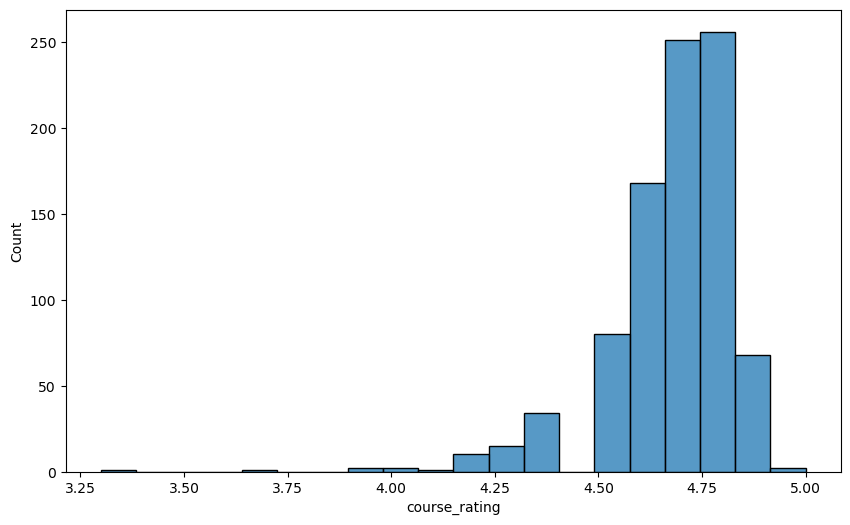

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['course_rating'], bins=20)
plt.show()

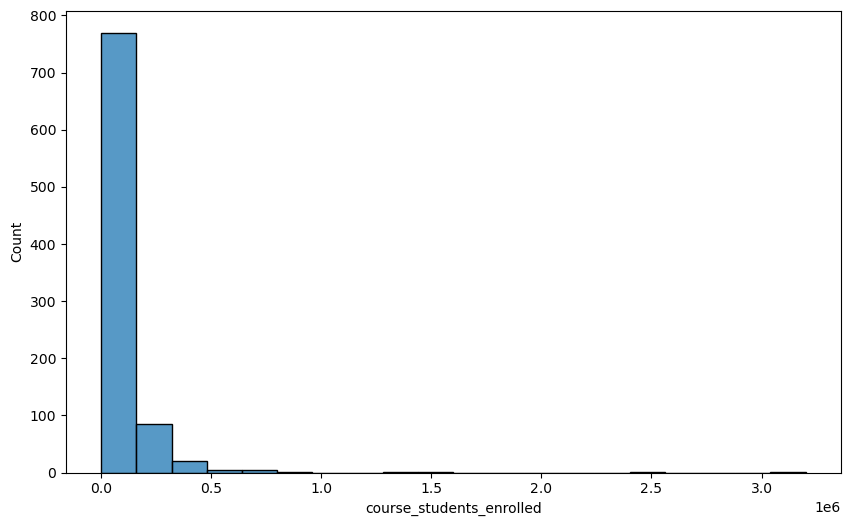

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(df['course_students_enrolled'], bins=20)
plt.show()

### Correlation Tests  
#### Spearman’s Rank Correlation  
- This method checks if there’s a consistent increasing or decreasing trend (does not have to be linear) between two numerical variables

#### Phi-K Correlation  
- Works for both categorical and numerical variables. It can detect non-linear patterns and is useful when you’re comparing variables of different type.

In [ ]:
spearman_corr = df["course_students_enrolled"].corr(
    df["course_rating"], method="spearman"
)
print(f"Spearman correlation coefficient: {spearman_corr:.3f}")

Spearman correlation coefficient: 0.027


**No statistical correlation between students enrolled and course rating.**

interval columns not set, guessing: ['course_rating', 'course_students_enrolled']


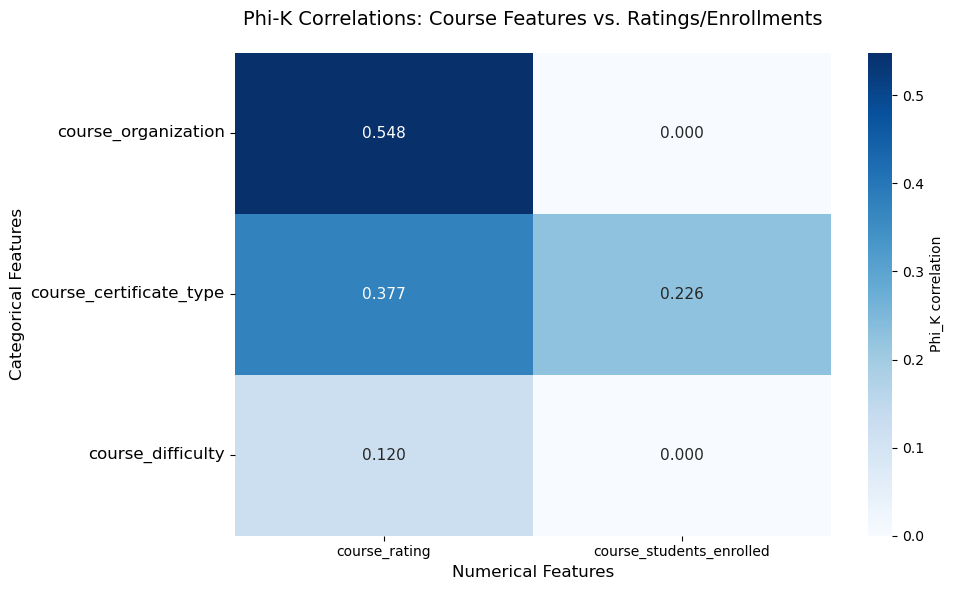

In [ ]:
import matplotlib.pyplot as plt
from phik import phik_matrix

cat_cols = ["course_organization", "course_certificate_type", "course_difficulty"]
num_cols = ["course_rating", "course_students_enrolled"]

phik_corr = df.phik_matrix().loc[cat_cols, num_cols].round(4)

plt.figure(figsize=(10, 6))
heatmap = sns.heatmap(
    phik_corr,
    annot=True,
    cmap="Blues",
    fmt=".3f",
    cbar_kws={"label": "Phi_K correlation"},
    annot_kws={"size": 11},
)

heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=0, ha="right", fontsize=12)
plt.title(
    "Phi-K Correlations: Course Features vs. Ratings/Enrollments", pad=20, fontsize=14
)
plt.xlabel("Numerical Features", fontsize=12)
plt.ylabel("Categorical Features", fontsize=12)
plt.tight_layout()
plt.show()

### Phi_K Value
**0.30–0.50 - Moderate association<br>**
**0.50–0.70 - Strong association<br>**
**0.70–1.00 - Very strong association <br>**

<br>
The result showcase that there is: <br>
- a Strong association between course organization and course rating. - 0.548<br>    
    
    Top-tier organizations consistently deliver high-rated courses.

    Brand trust matters: Learners may rate courses from reputable providers higher, regardless of content.


## Begin by pinpointing the Top organizations and courses.

## 1. Do more courses = more enrollments per organization ?

# Stage 1

In [ ]:
course_count = df.groupby("course_organization", observed=False)["course_title"].count()

top_org = (
    df.groupby("course_organization", observed=False)["course_students_enrolled"]
    .sum()
    .nlargest(10)
    .reset_index()
)

top_org["course_count"] = top_org["course_organization"].map(course_count)

top_org["custom_label"] = top_org.apply(
    lambda row: f"{row['course_students_enrolled']:,} students<br>{row['course_count']} courses",
    axis=1,
)

fig_top_org = px.bar(
    top_org,
    x="course_students_enrolled",
    y="course_organization",
    text="custom_label",
    title="<b>Top 10 Organizations by Total Students Enrolled</b>",
    color="course_students_enrolled",
    color_continuous_scale="purples",
)

fig_top_org.update_layout(
    coloraxis_showscale=False,
    xaxis=dict(
        visible=False,
        range=[0, top_org["course_students_enrolled"].max() * 1.4],
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False,
    width=1400,
    height=700,
    hovermode=False,
    yaxis_tickfont=dict(size=15, color="black"),
    yaxis=dict(categoryorder="total ascending"),
    yaxis_title=None,
)

fig_top_org.update_traces(
    textposition="outside",
    textfont=dict(size=14, color="black"),
    hovertemplate=("<b>%{y}</b><br>" "Total Enrolled: %{x:,}<br>" "<extra></extra>"),
)

fig_top_org.show()

### By observing the results we can clearly see several organizations with below 20 courses in the top 10 meaning :
- There is no linear relationship between having more courses = having more students enrolled .
- Organizations with fewer but well-designed or well-marketed courses outperform those with more.


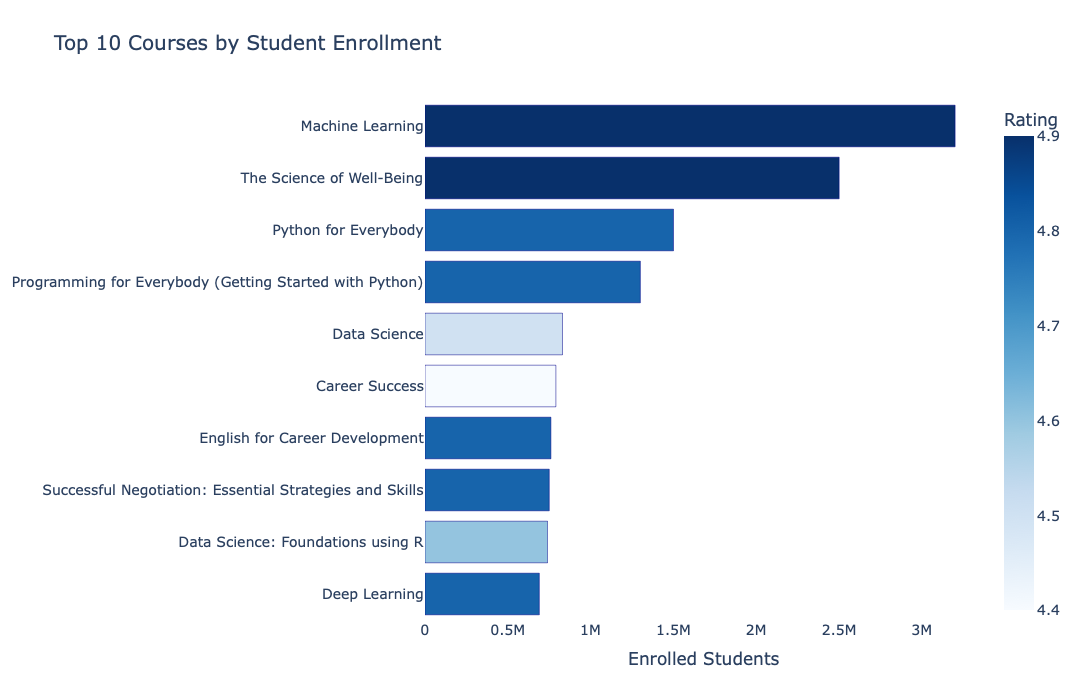

In [ ]:
top_courses = (
    df[
        [
            "course_title",
            "course_students_enrolled",
            "course_rating",
            "course_certificate_type",
            "course_organization",
        ]
    ]
    .sort_values(by="course_students_enrolled", ascending=False)
    .head(10)
)


fig_top_courses = px.bar(
    top_courses.sort_values(by="course_students_enrolled"),
    x="course_students_enrolled",
    y="course_title",
    title="Top 10 Courses by Student Enrollment",
    color="course_rating",
    color_continuous_scale="Blues",
    hover_data={
        "course_rating": True,
        "course_certificate_type": True,
        "course_organization": True,
        "course_title": False,
    },
    labels={
        "course_students_enrolled": "Enrolled Students",
        "course_rating": "Rating",
        "course_certificate_type": "Certificate Type",
        "course_organization": "Organization",
    },
    width=1200,
    height=700,
)

fig_top_courses.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(title="Enrolled Students", gridcolor="lightgrey", showgrid=False),
    yaxis=dict(title="Course Title", gridcolor="lightgrey", showgrid=False),
    font=dict(size=14),
    yaxis_title=None,
)

fig_top_courses.update_traces(marker_line_color="darkblue")

fig_top_courses.show()

### The top most enrolled courses have a very high rating indicating :
- It's popular for a ***reason*** . A strong correlation between popularity and learner satiscation.
- With the lowest rated course in the top 10 being 4.4 (Career Success).
- Having a total of 5 Courses and 5 Specializations in the top 10.

## 2. Does offering more courses result in more learner enrollment ?

/var/folders/xc/xj4d7v1504z3j_y20ccp78tc0000gn/T/ipykernel_8636/992581631.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



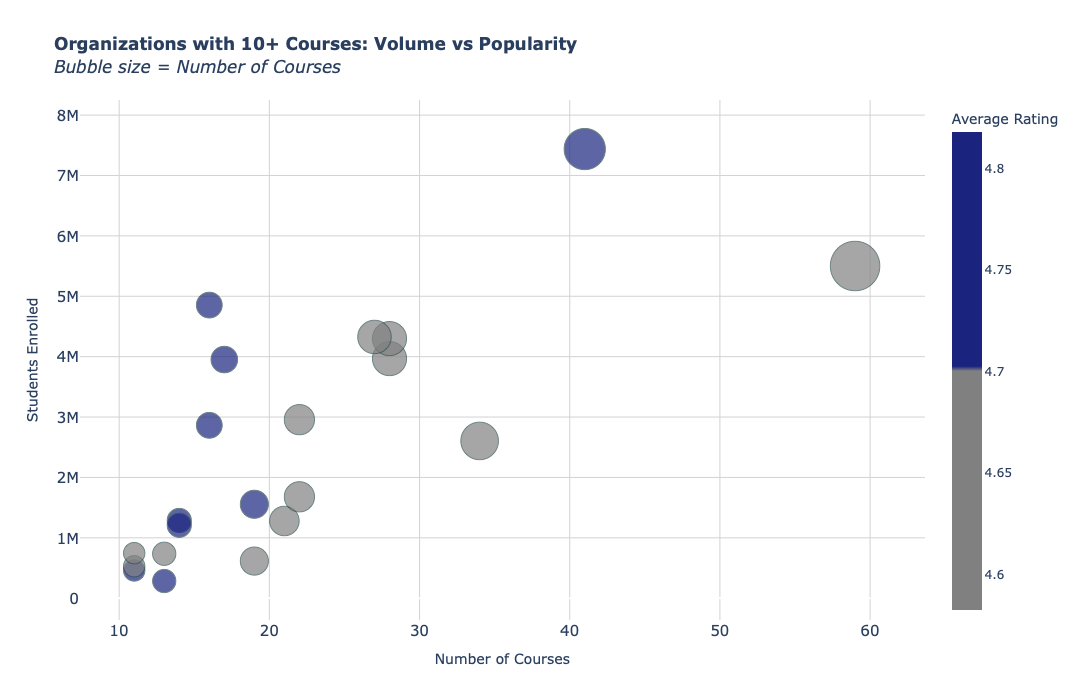

In [ ]:
num_courses = 10
summary = (
    df.groupby("course_organization")
    .agg(
        num_courses=("course_title", "count"),
        total_students=("course_students_enrolled", "sum"),
        avg_rating=("course_rating", "mean"),
    )
    .reset_index()
)

summary = summary[summary["num_courses"] > num_courses]

threshold = df["course_rating"].median()

fig_vol_vs_pop = px.scatter(
    summary,
    x="num_courses",
    y="total_students",
    size="num_courses",
    color="avg_rating",
    hover_name="course_organization",
    hover_data={"num_courses": True, "total_students": True, "avg_rating": ":.2f"},
    size_max=35,
    color_continuous_scale=[
        [0, "grey"],
        [0.5, "grey"],
        [0.51, "#1a237e"],
        [1, "#1a237e"],
    ],
    labels={
        "num_courses": "Number of Courses",
        "total_students": "Students Enrolled",
        "avg_rating": "Average Rating",
    },
    title="<b>Organizations with 10+ Courses: Volume vs Popularity</b><br><i>Bubble size = Number of Courses</i>",
    width=1200,
    height=700,
)

fig_vol_vs_pop.update_traces(
    marker=dict(line=dict(width=1, color="DarkSlateGrey")),
    hovertemplate=(
        "<b>%{hovertext}</b><br>"
        "Courses: %{x}<br>"
        "Students: %{y:,}<br>"
        "Rating: %{marker.color:.2f}<extra></extra>"
    ),
)

fig_vol_vs_pop.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(gridcolor="lightgrey", tickfont=dict(size=15)),
    yaxis=dict(gridcolor="lightgrey", tickfont=dict(size=15)),
)

fig_vol_vs_pop.show()

### To highlight performance differences, I color-coded the data points:

    Grey bubbles represent courses with ratings below 4.7

    Dark blue bubbles indicate courses with ratings of 4.7 or higher

This visual distinction makes it immediately clear which courses meet the quality threshold, making it easier to spot the highest-rated courses in the analysis.

**1. Most top-rated organizations have a sweet spot between 10-20 number of courses.**<br><br>
**2. One exception with 41 courses still maintains a high rating, but this is rare**<br>


/var/folders/xc/xj4d7v1504z3j_y20ccp78tc0000gn/T/ipykernel_8636/2901346020.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



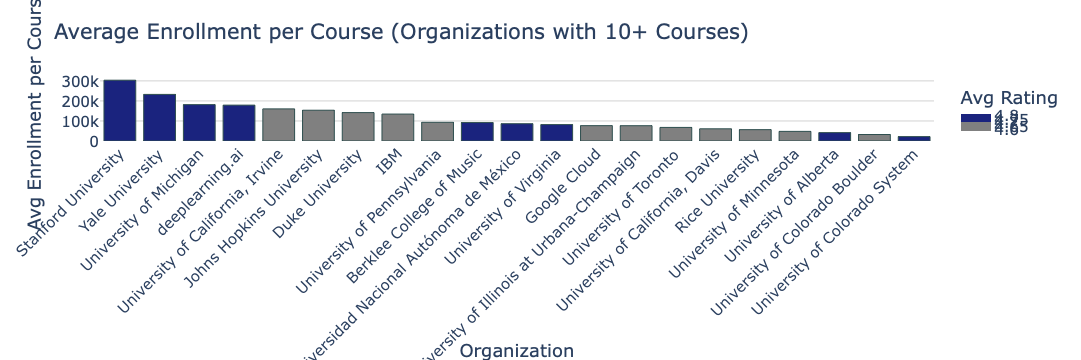

In [ ]:
org_stats = (
    df.groupby("course_organization")
    .agg(
        num_courses=("course_title", "count"),
        total_students=("course_students_enrolled", "sum"),
        avg_rating=("course_rating", "mean"),
    )
    .reset_index()
    .query("num_courses > 10")
)

org_stats["avg_enrollment_per_course"] = (
    org_stats["total_students"] / org_stats["num_courses"]
)

sorted_stats = org_stats.sort_values("avg_enrollment_per_course", ascending=False)

fig_avg_enroll = px.bar(
    sorted_stats,
    x="course_organization",
    y="avg_enrollment_per_course",
    color="avg_rating",
    color_continuous_scale=[
        [0, "grey"],
        [0.5, "grey"],
        [0.51, "#1a237e"],
        [1, "#1a237e"],
    ],
    labels={
        "course_organization": "Organization",
        "avg_enrollment_per_course": "Avg Enrollment per Course",
        "avg_rating": "Avg Rating",
    },
    title="Average Enrollment per Course (Organizations with 10+ Courses)",
    height=700,
)

fig_avg_enroll.update_traces(
    marker_line=dict(color="DarkSlateGrey", width=1),
    hovertemplate="<b>%{x}</b><br>Students/Course: %{y:,.0f}<br>Rating: %{marker.color:.2f}",
)

fig_avg_enroll.update_layout(
    xaxis_tickangle=-45,
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=True, gridcolor="lightgrey"),
    font=dict(size=15),
)

fig_avg_enroll.show()

**Organizations with top ratings don’t always have the highest average enrollment per course.** <br><br>
**As can be seen from the top 10 - where we have 5 courses rated (4.7+ in blue) and 5 rated (≤ 4.7, in grey)**
<br>

<br>
 While scale is important, what makes a course truly appealing? Let’s shift focus to how course structure — particularly difficulty level — influences learner behavior.


# Stage 2

## 3. How does course difficulty correlate with median enrollment numbers?

/var/folders/xc/xj4d7v1504z3j_y20ccp78tc0000gn/T/ipykernel_8636/738078107.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



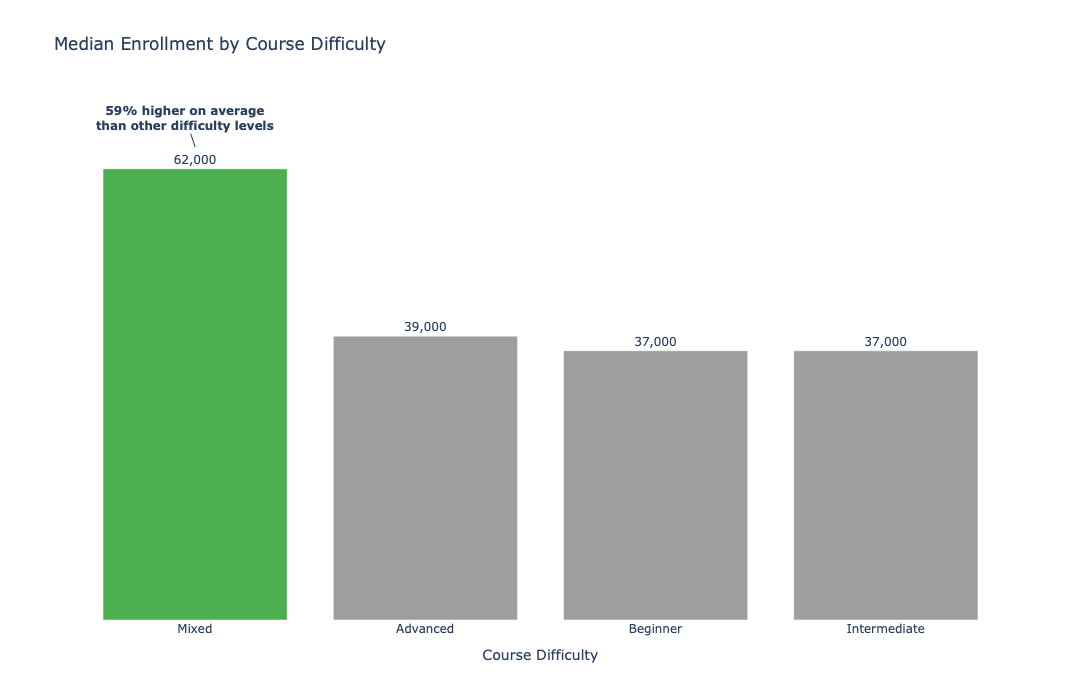

In [ ]:
difficulty = (
    df.groupby("course_difficulty", as_index=False)["course_students_enrolled"]
    .median()
    .sort_values("course_students_enrolled", ascending=False)
)

med_enroll_diff = px.bar(
    difficulty,
    x="course_difficulty",
    y="course_students_enrolled",
    color="course_difficulty",
    color_discrete_sequence=["#4CAF50", "#9E9E9E", "#9E9E9E", "#9E9E9E"],
    title="Median Enrollment by Course Difficulty",
    text="course_students_enrolled",
    labels={
        "course_students_enrolled": "Students Enrolled:",
    },
    height=700,
    width=1200,
)

med_enroll_diff.update_layout(
    xaxis_title="Course Difficulty",
    yaxis=dict(visible=False),
    showlegend=False,
    template="plotly_white",
)

med_enroll_diff.add_annotation(
    text="<b>59% higher on average<br>than other difficulty levels</b>",
    x="Mixed",
    y=65000,
    showarrow=True,
)

med_enroll_diff.update_traces(texttemplate="%{text:,}", textposition="outside")

med_enroll_diff.show()

### Mixed difficulty courses have almost 2x more median enrollment than any other difficulty level
- Likely reason being that it appeals to both beginner and advanced learners, maximizing its audience reach.<br>
- Beginner courses don't dominate as much as expected, it could be due to them being perceived as too basic/easy.<br>

 **Enrollment numbers tell us how many people sign up for courses, but they don't show the whole story.** <br><br>
 **What really matters is how students actually feel about their learning experience. Let's break down course ratings to see what's working well and where we can improve.** <br>

# Stage 3

## 4. How do learners rate courses across different difficulty levels ?

### - Does difficulty level correlate with learner satisfaction ?


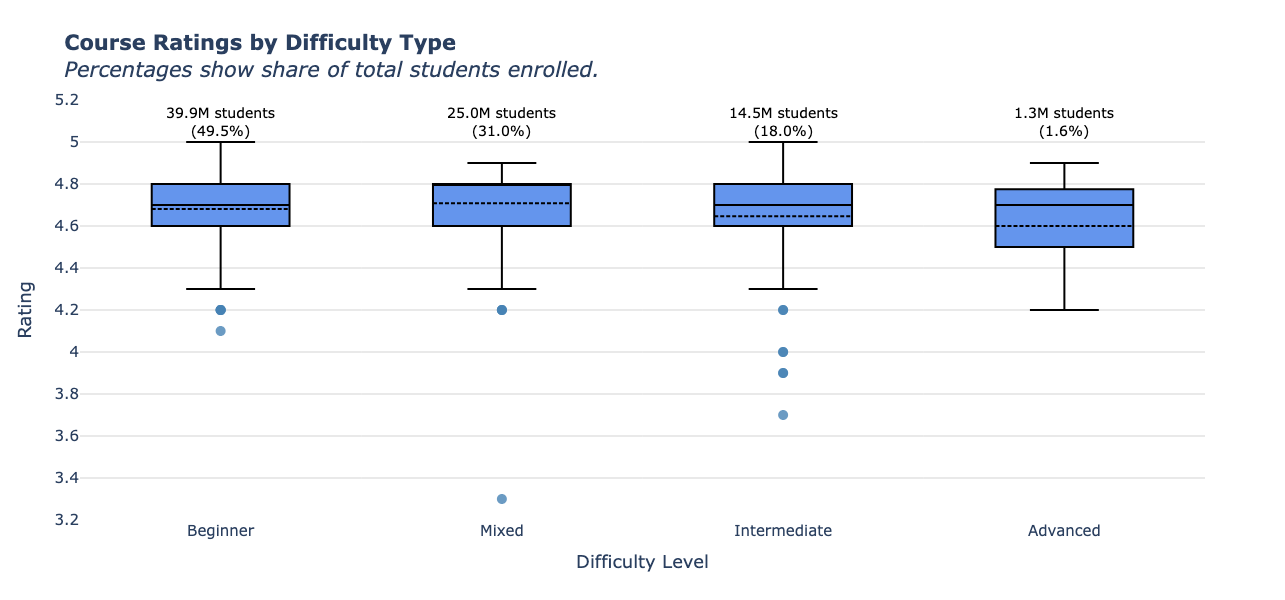

In [ ]:
fig_diff_ratings = px.box(
    df,
    x="course_difficulty",
    y="course_rating",
    category_orders={
        "course_difficulty": ["Beginner", "Mixed", "Intermediate", "Advanced"]
    },
    title="<b>Course Ratings by Difficulty Type</b><br><i>Percentages show share of total students enrolled.</i>",
    labels={"course_rating": "Rating", "course_difficulty": "Difficulty Level"},
    color="course_difficulty",
)

total_students = df["course_students_enrolled"].sum()

for level in ["Beginner", "Intermediate", "Mixed", "Advanced"]:
    level_students = df[df["course_difficulty"] == level][
        "course_students_enrolled"
    ].sum()
    percentage = (level_students / total_students) * 100

    annotation_text = f"{level_students/1e6:.1f}M students<br>({percentage:.1f}%)"

    fig_diff_ratings.add_annotation(
        x=level,
        y=5.10,
        text=annotation_text,
        showarrow=False,
        font_size=14,
        font_color="black",
        align="center",
    )

fig_diff_ratings.update_traces(
    fillcolor="rgb(100, 149, 237)",
    line=dict(color="black", width=2),
    marker=dict(color="rgb(70, 130, 180)", size=10, opacity=0.8),
    boxmean=True,
    hovertemplate="<b>%{x}</b><br>Rating: %{y:.2f}<extra></extra>",
)

fig_diff_ratings.update_layout(
    width=1200,
    height=600,
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False,
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=True, gridcolor="lightgrey"),
    font=dict(size=15),
)

fig_diff_ratings.show()

1. Beginner Courses **(49.5% of total)**:
**-  Highest reach, high satisfaction (median: 4.7, mean: 4.68).**
- Interpretation: The platform successfully attracts and retains entry-level learners with quality content.

2. Mixed Courses **(31% of total)**:
**- Top-rated (median: 4.8, mean: 4.7) and second-highest enrollment.**
- Interpretation: "Goldilocks zone" for learners - not too hard, not too easy

3. Intermediate **(18%)** & Advanced **(1.6%)** Courses:
- Solid ratings (median: 4.7 for both) but low enrollment. <br>
**Critical Insight:** <br>
 **- Learnes may switch to other platforms for advanced topics.**

## 5. How do course ratings and enrollment levels vary by certificate type?


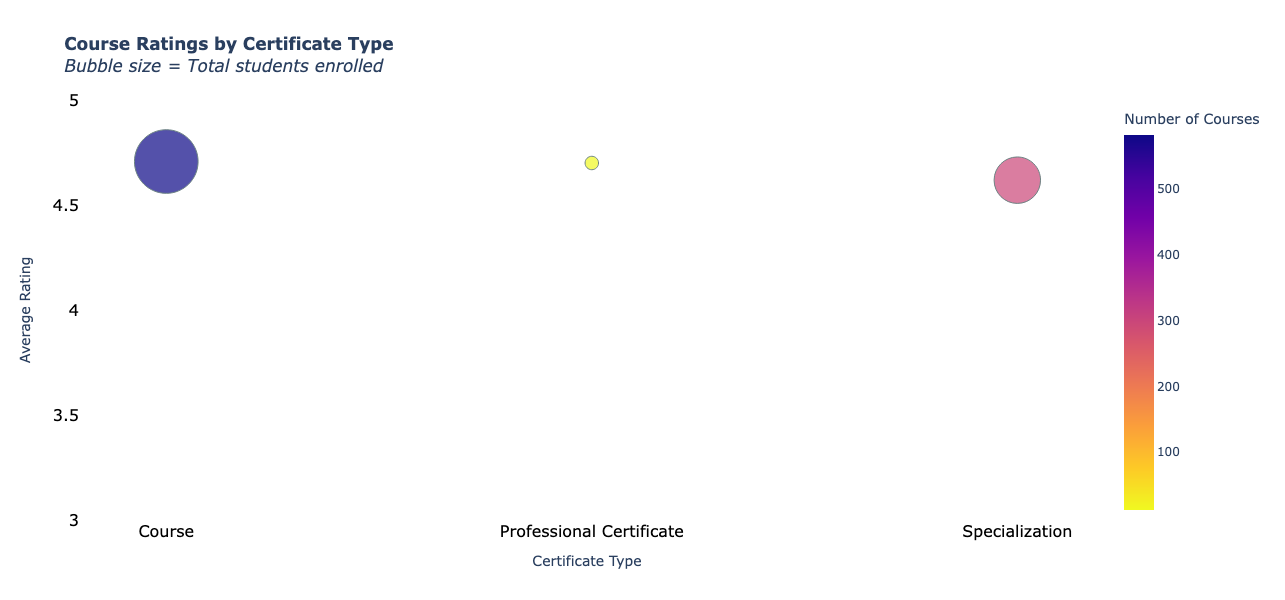

In [ ]:
cert_data = (
    df.groupby("course_certificate_type")
    .agg(
        avg_rating=("course_rating", "mean"),
        median_rating=("course_rating", "median"),
        total_enrolled=("course_students_enrolled", "sum"),
        num_courses=("course_title", "nunique"),
    )
    .reset_index()
)

fig_cert_ratings = px.scatter(
    cert_data,
    x="course_certificate_type",
    y="avg_rating",
    size="total_enrolled",
    color="num_courses",
    color_continuous_scale="plasma_r",
    title="<b>Course Ratings by Certificate Type</b><br><i>Bubble size = Total students enrolled</i>",
    labels={
        "avg_rating": "Average Rating",
        "course_certificate_type": "Certificate Type",
        "num_courses": "Number of Courses",
        "total_enrolled": "Total Enrolled",
    },
    hover_data=["median_rating"],
    size_max=45,
)

fig_cert_ratings.update_layout(
    plot_bgcolor="white",
    yaxis_range=[3, 5],
    xaxis_tickfont=dict(size=16, color="black"),
    yaxis_tickfont=dict(size=16, color="black"),
    hovermode="x unified",
    width=1200,
    height=600,
)

fig_cert_ratings.update_traces(
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Avg Rating: %{y:.2f}<br>"
        "Median Rating: %{customdata[0]:.2f}<br>"
        "Number of Courses: %{marker.color}<br>"
        "Students: %{marker.size:,}"
    ),
    marker=dict(line=dict(width=1, color="DarkSlateGrey")),
)

fig_cert_ratings.show()

 1. Courses are the foundation of the platform
   - with the most people enrolled **(51M)** and **highest median(4.70), average(4.71)** ratings.
 2. Professional certificates have a high satisfaction but a very limited offering
   - with  .**(avg. rating 4.70)**, but just- **12 courses.**
 3. Specializations have a very strong enrollment - **27M**, but a slightly lower satiscaftion **(avg. rating - 4.62)**
<br><br>

# Summary ✅ :     
    1.Quality > Quantity
    Top-performing organizations thrive with below 20 courses—proving fewer, better courses beat bloated catalogs.

    2.Mixed Difficulty is a winner!
    Courses that are "not too easy, not too hard" have 2× higher enrollment and the best ratings (4.8 median).

    3.Beginner Courses = Gateway
    Highest reach (39.9M students) and strong ratings (4.7 median)—key for onboarding new learners.

    4.Advanced Courses Struggle
    Solid ratings (4.7 median) but low enrollment (1.3M)—risk of losing learners to other platforms.

    5.Professional Certificates = Hidden Gem
    Tiny offering (12 courses) but top-tier satisfaction (4.7 avg)—untapped growth potential.

    6.Popularity Signals Quality
    Top 10 enrolled courses all rate ≥4.4—learners reliably gravitate to high-quality content.

<br>


# Strategic Recommendations:
**1. Prioritize quality over quantity: Partners should maybe optimize current course offerings before considering expansions.** <br><br>
**2. Invest in mixed-difficulty content: Leverage their proven appeal to broader audiences.** <br><br>
**3. Expand professional certificates: In order to gain more popularity with advanced learners**
<br><br><br>


## Suggestions about how the analysis could be improved :
**1. Add paid vs. free course segmentation to:**

        Compare enrollment patterns (Do free courses attract more learners but have lower completion rates?)

        Analyze rating differences (Are paid courses perceived as higher quality?)

**2. If data includes launch dates or update timestamps:**

    Track rating changes after course updates

    Identify seasonal enrollment patterns

**3. Add course duration (hours/weeks) to assess:**
        
    Relationship between length and satisfaction

    Optimal duration for different difficulty levels

**4. If data includes student demographics:**

    Identify regional preferences for certificate types

    Adapt difficulty levels by market (e.g., advanced courses may perform better in certain regions)